In [1]:
# import classy module
from classy import Class

In [2]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'tCl,pCl,lCl,mPknw','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()

In [3]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
import numpy as np
from plotting_utils import plot_segments

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=True)
rc('font', family='serif', size=15)

rcParams.update({
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

In [ ]:
# Don't use IR resummed powerspectra (yet)
use_IR_resum = 1

# galaxy bias:
b1 = np.array([1.5])
b2 = np.array([-1.])
bG2 = np.array([-0.35])
d1 = np.array([1.])
d2 = np.array([0.5])
d3 = np.array([1.])
 
# to match Dennis' noise contribution: https://arxiv.org/pdf/2204.15628 eq. 2.20

# noise bias:
n_bar = 0.000779126064152255*h**3  # Unit conversion since Dennis uses 
P_eps = np.array([1./n_bar])



k_min, k_max = 5e-4, 0.2
z = np.array([0.7,0.8])

k = np.logspace(np.log10(k_min), np.log10(k_max), k_size)
z = np.linspace(z_min, z_max, z_size)



In [7]:

def make_k_array_np(k_min, delta_k, n_steps):
    # 1) indices 0..n_steps-1 in a 3×3 grid
    I, J, K = np.indices((n_steps,)*3)
    # 2) pick only those with i<=j<=k
    mask = (I <= J) & (J <= K)

    # 3) stack the valid (i,j,k) triples
    ijk = np.stack((I[mask], J[mask], K[mask]), axis=1)

    # 4) map back to actual k values
    return k_min + delta_k * ijk

# example:
arr = make_k_array_np(0.0, 0.5, 5)
print(arr.shape)   # same as above
print(arr)

(35, 3)
[[0.  0.  0. ]
 [0.  0.  0.5]
 [0.  0.  1. ]
 [0.  0.  1.5]
 [0.  0.  2. ]
 [0.  0.5 0.5]
 [0.  0.5 1. ]
 [0.  0.5 1.5]
 [0.  0.5 2. ]
 [0.  1.  1. ]
 [0.  1.  1.5]
 [0.  1.  2. ]
 [0.  1.5 1.5]
 [0.  1.5 2. ]
 [0.  2.  2. ]
 [0.5 0.5 0.5]
 [0.5 0.5 1. ]
 [0.5 0.5 1.5]
 [0.5 0.5 2. ]
 [0.5 1.  1. ]
 [0.5 1.  1.5]
 [0.5 1.  2. ]
 [0.5 1.5 1.5]
 [0.5 1.5 2. ]
 [0.5 2.  2. ]
 [1.  1.  1. ]
 [1.  1.  1.5]
 [1.  1.  2. ]
 [1.  1.5 1.5]
 [1.  1.5 2. ]
 [1.  2.  2. ]
 [1.5 1.5 1.5]
 [1.5 1.5 2. ]
 [1.5 2.  2. ]
 [2.  2.  2. ]]


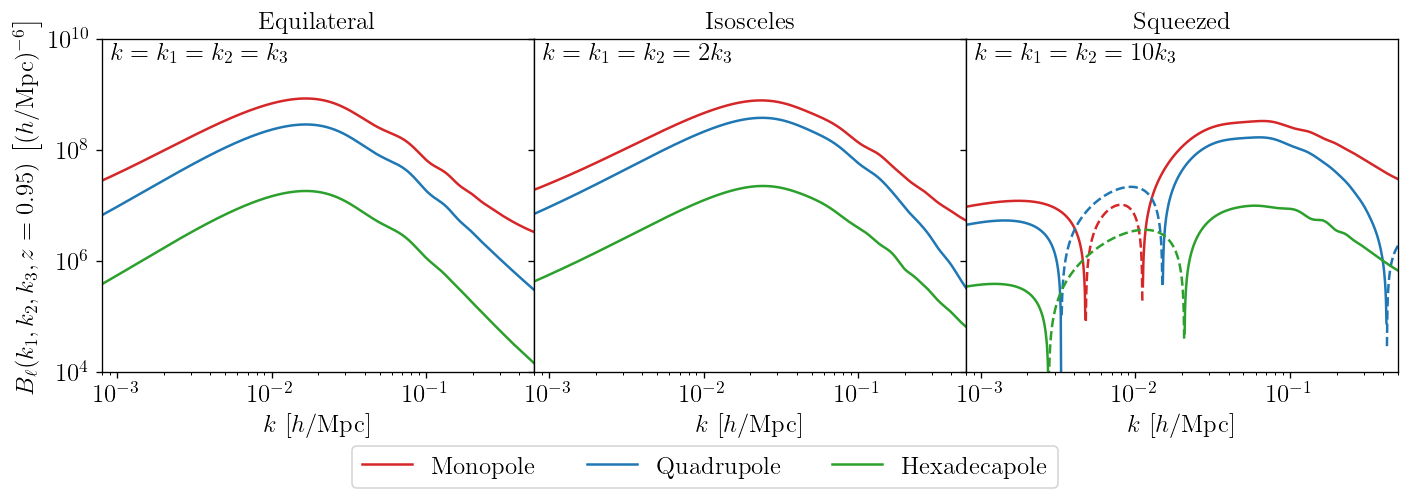

In [5]:
triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in

# multipole l
l_s = [0, 2, 4]
labels = ["Monopole", "Quadrupole", "Hexadecapole"]
colors = ["tab:red", "tab:blue", "tab:green"]
ls = ["solid", "dashed", "dotted"]


#fig, ax = plt.subplots(3, 1, figsize=(7, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1], 'hspace': 0})

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharey=True, gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0})

dx = 0.02
idx = 0
use_labels= True
for z_ in z:
    for type in triangle_types:
        for l_idx, l in enumerate(l_s):
            Bk_l = LambdaCDM.get_bk_lin_multipoles_configs(use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, type, k, l, z, k_size, z_size)
            Bk_l_1D = Bk_l[:, 0]
            plot_segments(ax[idx], k/h, Bk_l_1D*h**6, colors[l_idx], rf"{labels[l_idx]}", "solid", use_labels)
            #ax[idx].plot(k/h, Bk_l_1D*h**6)
        use_labels = False
        ax[idx].set_xscale("log")
        ax[idx].set_yscale("log")
        ax[idx].set_xlabel(rf"$k$ $\left[h/\mathrm{{Mpc}}\right]$")
        if type == "equi":
            ax[idx].set_ylabel(rf"$B_\ell(k_1, k_2, k_3, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for equilateral
            ax[idx].annotate("$k=k_1=k_2=k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Equilateral")
        elif type == "iso":
            #ax[idx].set_ylabel(rf"$B_\ell(k, 2k, 2k, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for isosceles
            ax[idx].annotate("$k=k_1=k_2=2k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Isosceles")
        elif type == "squeezed":
            #ax[idx].set_ylabel(rf"$B_\ell(k, k, k/10, z={z_})$ $\left[(h/\mathrm{{Mpc}})^{{-6}}\right]$")
            # Add title for squeezed
            ax[idx].annotate("$k=k_1=k_2=10k_3$", xy=(dx, 0.94), xycoords="axes fraction", ha="left", fontsize=15)
            ax[idx].set_title("Squeezed")

        ax[idx].set_ylim(1e4, 1.e10)
        ax[idx].set_xlim(8e-4, k_max)
        idx += 1
fig.legend(loc='center', bbox_to_anchor=(0.5, -0.005), ncol=3)

plt.tight_layout()
plt.savefig(f"bispectrum_multipoles_configs.pdf", bbox_inches='tight')
plt.show()






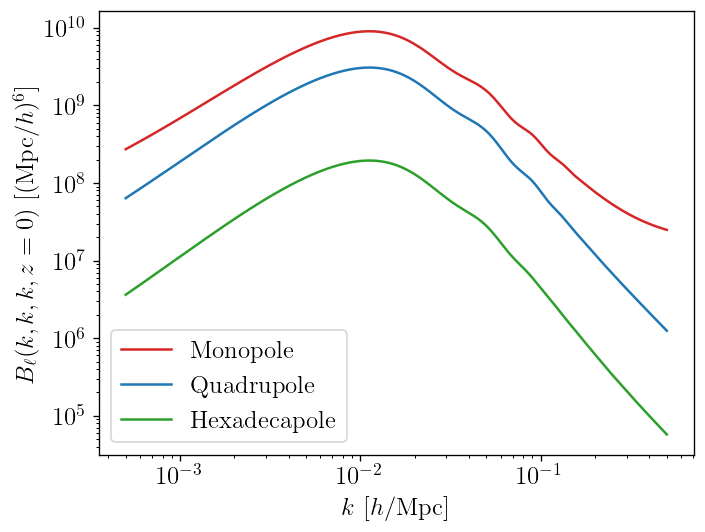

In [6]:
triangle_types = ["equi", "iso", "squeezed"]        # 3 types of triangle configs that we are interest in

# multipole l
l_s = [0, 2, 4]
labels = ["Monopole", "Quadrupole", "Hexadecapole"]
colors = ["tab:red", "tab:blue", "tab:green"]
ls = ["solid", "dashed", "dotted"]


#fig, ax = plt.subplots(3, 1, figsize=(7, 12), sharex=True, gridspec_kw={'height_ratios': [1, 1, 1], 'hspace': 0})


dx = 0.02
idx = 0
use_labels= True

for idx, l in enumerate(l_s):
    Bk_l = LambdaCDM.get_bk_lin_multipoles_configs(use_IR_resum, b1, b2, bG2, d1, d2, d3, P_eps, "equi", k, l, z, k_size, z_size)
    Bk_l_1D = Bk_l[:, 0]
    plt.plot(k, Bk_l_1D, label=labels[idx], color=colors[idx])
plt.xscale("log")
plt.yscale("log")
plt.ylabel(r"$B_\ell(k, k, k, z=0)$ $[(\mathrm{{Mpc}}/h)^6]$")
plt.xlabel(r"$k$ $[h/\mathrm{{Mpc}}]$")
plt.legend()
plt.savefig("bispectrum_single_showcase.pdf", bbox_inches='tight')